# Resource Estimation for the EC Discrete Logarithm Problem

This notebook produces gate-count resource estimates for solving the Elliptic Curve Discrete Logarithm Problem (ECDLP) via Shor's algorithm, from 4-bit toy curves up to **256-bit** (secp256k1-scale).

All curves use the equation $y^2 = x^3 + 7 \pmod{p}$ (i.e. $a = 0$, $b = 7$), matching the form of secp256k1.

## Estimation strategy

The full ECDLP algorithm performs $2n$ controlled EC point additions ($n$ for the generator multiplication, $n$ for the public key multiplication), plus Hadamard preparation and inverse QFT on two $n$-qubit QPE registers.

**Key insight**: every call to `q_ec_add_inpl` has the same gate structure regardless of the classical point used — only the modulus bit-width matters. We exploit this by:

1. Counting gates for a **single** controlled `q_ec_add_inpl` via `@count_ops`
2. Counting the **overhead** (Hadamard, QFT, encoding, measurement) separately
3. Computing: $\text{total} = 2n \times \text{single\_add} + \text{overhead}$

This avoids tracing $2n = 512$ full EC additions at 256-bit, making estimation feasible without kernel crashes.

In [1]:
import gc
import json
import math
import time
import collections

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import qrisp
from qrisp import (
    QuantumModulus, QuantumFloat, QuantumBool,
    h, QFT, merge, measure, control, gidney_adder, count_ops,
)
from qrisp.alg_primitives.arithmetic.jasp_arithmetic.jasp_bigintiger import BigInteger

import src.classical.ec_arithmetic as clECarithm
import src.quantum.ec_arithmetic as qECarithm

# Curve equation: y² = x³ + 7 (mod p)
A, B = 0, 7

print("Imports OK")

Imports OK


## 1. Curve Parameter Setup

We collect EC curve parameters for a range of bit sizes. Small curves (4–21 bit) come from `curves_and_keys.json`; larger ones (32–256 bit) are generated on the fly by finding a prime of the desired bit length and a point on $y^2 = x^3 + 7 \pmod{p}$.

In [2]:
from sympy import nextprime
from sympy.ntheory import sqrt_mod


def find_curve_point(p, a=0, b=7):
    """Find a point on y² = x³ + ax + b (mod p) by trial."""
    for x in range(1, min(p, 10_000)):
        rhs = (pow(x, 3, p) + a * x + b) % p
        if pow(rhs, (p - 1) // 2, p) == 1:
            y = sqrt_mod(rhs, p)
            if y is not None:
                return [x, int(y)]
    raise ValueError(f"No point found on curve mod {p}")


def generate_curve_entry(bit_length):
    """Generate a curve entry for a given bit length."""
    p = int(nextprime(2**(bit_length - 1) + 2**(bit_length - 2)))
    G = find_curve_point(p, A, B)
    k = 3
    curve = clECarithm.EllCurve(A, B, p)
    P_point = clECarithm.ell_mult_add(
        clECarithm.EllPoint(*G), clECarithm.EllZero, k, curve
    )
    return {
        "bit_length": bit_length,
        "prime": p,
        "generator_point": G,
        "private_key": k,
        "public_key": [P_point.x, P_point.y],
    }


# --- Load small curves from JSON ---
with open("curves_and_keys.json") as f:
    curves_json = json.load(f)

all_entries = {}
for entry in curves_json:
    all_entries[entry["bit_length"]] = entry

# --- Generate larger curves ---
for bits in [32, 48, 64, 128, 256]:
    if bits not in all_entries:
        print(f"Generating {bits}-bit curve...", end=" ", flush=True)
        all_entries[bits] = generate_curve_entry(bits)
        print(f"p = {all_entries[bits]['prime']}")

# Target bit sizes for resource estimation (ascending order)
TARGET_SIZES = [4, 8, 16, 32, 64, 128, 256]
print(f"\nTarget bit sizes: {TARGET_SIZES}")
print(f"All available:    {sorted(all_entries.keys())}")

Generating 32-bit curve... p = 3221225473
Generating 48-bit curve... p = 211106232533047
Generating 64-bit curve... p = 13835058055282163729
Generating 128-bit curve... p = 255211775190703847597530955573826158773
Generating 256-bit curve... p = 86844066927987146567678238756515930889952488499230423029593188005934847230001

Target bit sizes: [4, 8, 16, 32, 64, 128, 256]
All available:    [4, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 32, 48, 64, 128, 256]


## 2. Per-Addition Gate Counting

Each iteration of Shor's ECDLP loop calls `q_ec_add_inpl` — a controlled elliptic-curve point addition that internally performs:

- Two Kaliski modular inversions (each with a $2n$-iteration loop)
- Multiple Montgomery modular multiplications via Qrisp's injection mechanism
- Several modular additions / subtractions

The gate count depends on the prime's bit-width $n$ but **not** on the classical point coordinates. We define two counting functions:

| Function | What it counts |
|---|---|
| `count_single_ec_add` | One controlled `q_ec_add_inpl` (the dominant cost) |
| `count_overhead` | Hadamard prep + initial encoding + inverse QFT + measurement |

The full algorithm cost is then: $\;\text{total} = 2n \times \texttt{single\_add} + \texttt{overhead}$

In [3]:
def count_single_ec_add(entry):
    """Count gates for one controlled q_ec_add_inpl at the given bit size."""
    bit_length = entry["bit_length"]
    p_int = entry["prime"]
    G = entry["generator_point"]

    bi_size = math.ceil(bit_length / 32)
    p_bi = BigInteger.create_static(p_int, bi_size)
    G0_bi = BigInteger.create_static(int(G[0]), bi_size)
    G1_bi = BigInteger.create_static(int(G[1]), bi_size)

    @count_ops(meas_behavior="0")
    def _count():
        res_0 = QuantumModulus(p_bi, inpl_adder=gidney_adder)
        res_1 = QuantumModulus(p_bi, inpl_adder=gidney_adder)
        ctrl_qb = QuantumBool()
        qECarithm.q_ec_add_inpl(
            [res_0, res_1], (G0_bi, G1_bi), p_bi, ctrl=ctrl_qb
        )

    return _count()


def count_overhead(entry):
    """Count gates for H + encoding + QFT + measurement (everything except EC additions)."""
    bit_length = entry["bit_length"]
    p_int = entry["prime"]
    G = entry["generator_point"]

    bi_size = math.ceil(bit_length / 32)
    p_bi = BigInteger.create_static(p_int, bi_size)
    G0_bi = BigInteger.create_static(int(G[0]), bi_size)
    G1_bi = BigInteger.create_static(int(G[1]), bi_size)
    mod_2n = BigInteger.create_static(2**bit_length, bi_size + 1)

    @count_ops(meas_behavior="0")
    def _count():
        # Ancilla registers (encode generator point)
        res_0 = QuantumModulus(p_bi, inpl_adder=gidney_adder)
        res_0[:] = G0_bi
        res_1 = QuantumModulus(p_bi, inpl_adder=gidney_adder)
        res_1[:] = G1_bi
        # QPE registers
        x1 = QuantumModulus(mod_2n, inpl_adder=gidney_adder)
        x2 = QuantumModulus(mod_2n, inpl_adder=gidney_adder)
        h(x1)
        h(x2)
        # Inverse QFT + measurement
        QFT(x1, inv=True)
        QFT(x2, inv=True)
        qrisp.measure_to_big_integer(x1, bi_size)
        qrisp.measure_to_big_integer(x2, bi_size)

    return _count()


print("Counting functions defined.")

Counting functions defined.


### Run progressive per-addition counting

We count gates progressively from small to large bit sizes. Results are stored incrementally so partial data survives if the kernel crashes on the larger instances.

> **Expected timings**: 4–16 bit: seconds. 32–64 bit: tens of seconds. 128 bit: minutes. 256 bit: potentially tens of minutes or more, depending on hardware.

In [4]:
add_results = {}       # bit_length → gate dict
overhead_results = {}  # bit_length → gate dict
timing = {}            # bit_length → seconds (for single-add trace)

for bits in TARGET_SIZES:
    entry = all_entries[bits]
    print(f"\n{'='*60}")
    print(f"{bits}-bit  (p = {entry['prime']})")
    print(f"{'='*60}")

    # --- Single controlled EC addition ---
    print(f"  Single EC addition...", end=" ", flush=True)
    t0 = time.time()
    try:
        add_ops = count_single_ec_add(entry)
        elapsed = time.time() - t0
        add_results[bits] = add_ops
        timing[bits] = elapsed
        t_count = add_ops.get("t", 0) + add_ops.get("t_dg", 0)
        cx_count = add_ops.get("cx", 0)
        total = sum(add_ops.values())
        print(f"done in {elapsed:.1f}s  (T={t_count:,}, CX={cx_count:,}, total={total:,})")
    except Exception as e:
        elapsed = time.time() - t0
        print(f"FAILED after {elapsed:.1f}s: {e}")
        timing[bits] = elapsed
        gc.collect()
        continue

    # --- Overhead (H + QFT + encoding + measurement) ---
    print(f"  Overhead...", end=" ", flush=True)
    t0_oh = time.time()
    try:
        oh_ops = count_overhead(entry)
        elapsed_oh = time.time() - t0_oh
        overhead_results[bits] = oh_ops
        print(f"done in {elapsed_oh:.1f}s  (total={sum(oh_ops.values()):,})")
    except Exception as e:
        elapsed_oh = time.time() - t0_oh
        print(f"FAILED after {elapsed_oh:.1f}s: {e}")

    gc.collect()

print(f"\n{'='*60}")
print(f"Completed {len(add_results)}/{len(TARGET_SIZES)} bit sizes.")


4-bit  (p = 13)
  Single EC addition... done in 27.4s  (T=32,786, CX=74,092, total=146,379)
  Overhead... done in 0.6s  (total=147)

8-bit  (p = 163)
  Single EC addition... done in 7.6s  (T=43,954, CX=97,632, total=194,415)
  Overhead... done in 0.2s  (total=445)

16-bit  (p = 32803)
  Single EC addition... done in 11.2s  (T=71,630, CX=158,172, total=316,718)
  Overhead... done in 0.2s  (total=1,529)

32-bit  (p = 3221225473)
  Single EC addition... done in 20.4s  (T=151,474, CX=334,437, total=671,499)
  Overhead... done in 0.2s  (total=5,588)

64-bit  (p = 13835058055282163729)
  Single EC addition... done in 588.6s  (T=7,068,330, CX=16,107,297, total=31,124,515)
  Overhead... done in 0.6s  (total=21,412)

128-bit  (p = 255211775190703847597530955573826158773)
  Single EC addition... done in 2291.5s  (T=28,172,918, CX=64,149,757, total=123,847,165)
  Overhead... done in 0.8s  (total=83,774)

256-bit  (p = 86844066927987146567678238756515930889952488499230423029593188005934847230001)

## 3. Full-Algorithm Resource Estimates

The full ECDLP Shor circuit for an $n$-bit prime consists of:

$$\text{Total gates} = 2n \times \text{(single EC addition)} + \text{overhead}$$

The overhead includes Hadamard preparation ($2n$ gates), initial generator-point encoding ($\leq 2n$ X-gates), two inverse QFTs ($\sim n^2$ controlled-phase gates each), and final measurement ($2n$ measurements).

For the 256-bit case this is $2 \times 256 = 512$ controlled EC additions — mirroring the scale of secp256k1 (Bitcoin / Ethereum).

In [5]:
rows = []
for bits in sorted(add_results.keys()):
    add_ops = add_results[bits]
    oh_ops = overhead_results.get(bits, {})
    n = bits

    # Full algorithm = 2n × single_add + overhead
    full_ops = collections.Counter()
    for gate, count in add_ops.items():
        full_ops[gate] += count * 2 * n
    for gate, count in oh_ops.items():
        full_ops[gate] += count

    t_count = full_ops.get("t", 0) + full_ops.get("t_dg", 0)
    cnot_equiv = full_ops.get("cx", 0) + 0.5 * full_ops.get("c_if_cz", 0)
    total = sum(full_ops.values())

    rows.append({
        "n (bits)": bits,
        "Additions (2n)": 2 * n,
        "T-gates": t_count,
        "CNOT-equiv": int(cnot_equiv),
        "Total gates": total,
        "Trace time (s)": round(timing.get(bits, 0), 1),
    })

df = pd.DataFrame(rows)
print("=" * 95)
print("ECDLP Full-Algorithm Resource Estimates")
print("Formula: total = 2n × (single EC addition) + overhead")
print("=" * 95)
print(df.to_string(index=False))
print("=" * 95)

# Print raw per-addition breakdown for the largest completed size
largest_bits = max(add_results.keys())
print(f"\n{largest_bits}-bit per-addition gate breakdown:")
for gate, count in sorted(add_results[largest_bits].items(), key=lambda x: -x[1]):
    print(f"  {gate:>15}: {count:>12,}")

ECDLP Full-Algorithm Resource Estimates
Formula: total = 2n × (single EC addition) + overhead
 n (bits)  Additions (2n)     T-gates   CNOT-equiv  Total gates  Trace time (s)
        4               8      262288       592788      1171179            27.4
        8              16      703264      1562280      3111085             7.6
       16              32     2292160      5062096     10136505            11.2
       32              64     9694336     21406176     42981524            20.4
       64             128   904746240   2061742528   3983959332           588.6
      128             256  7212267008  16422371200  31704958014          2291.5
      256             512 57760265216 131261700864 253428535949          8545.0

256-bit per-addition gate breakdown:
               cx:  256,370,251
                h:   76,028,379
             t_dg:   57,728,770
                t:   55,084,248
                s:   23,575,341
          measure:   23,575,341
                x:    2,260,840
    

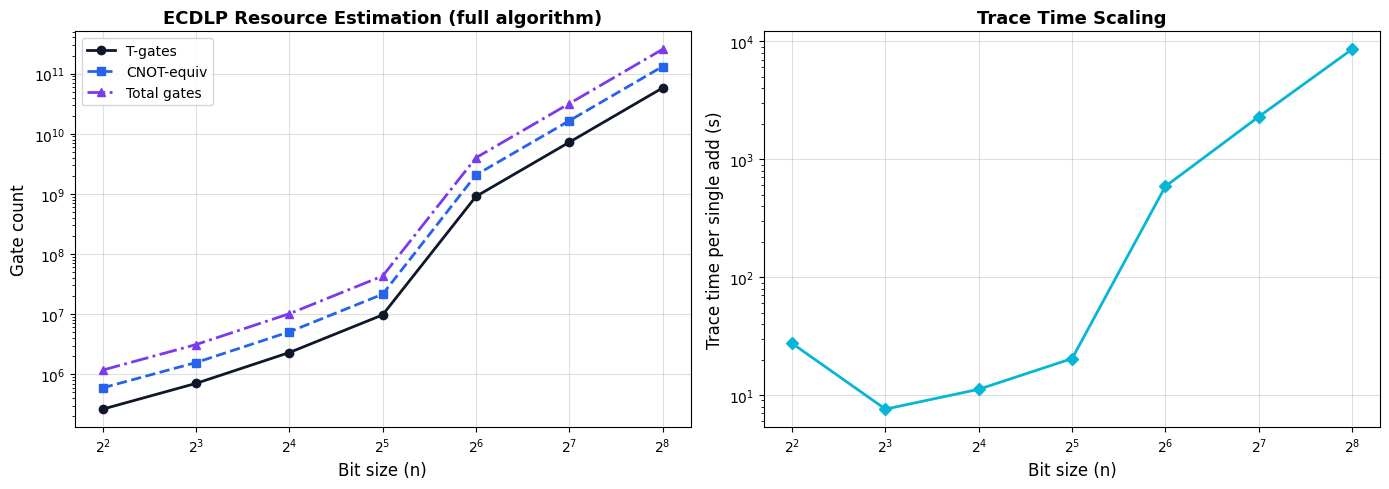


Power-law fit: T_gates ~ n^3.16
  (fit intercept: 9.61e+02)


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Left: gate counts vs bit size ---
style = {
    "T-gates":     {"color": "#0f172a", "marker": "o", "ls": "-"},
    "CNOT-equiv":  {"color": "#2563eb", "marker": "s", "ls": "--"},
    "Total gates": {"color": "#7c3aed", "marker": "^", "ls": "-."},
}

for label, col in [("T-gates", "T-gates"), ("CNOT-equiv", "CNOT-equiv"), ("Total gates", "Total gates")]:
    s = style[label]
    axes[0].plot(df["n (bits)"], df[col], label=label,
                 color=s["color"], marker=s["marker"], linestyle=s["ls"],
                 linewidth=2, markersize=6)

axes[0].set_xlabel("Bit size (n)", fontsize=12)
axes[0].set_ylabel("Gate count", fontsize=12)
axes[0].set_title("ECDLP Resource Estimation (full algorithm)", fontsize=13, fontweight="bold")
axes[0].set_xscale("log", base=2)
axes[0].set_yscale("log")
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.4)

# --- Right: trace time per single add ---
axes[1].plot(df["n (bits)"], df["Trace time (s)"], "D-",
             color="#06b6d4", linewidth=2, markersize=6)
axes[1].set_xlabel("Bit size (n)", fontsize=12)
axes[1].set_ylabel("Trace time per single add (s)", fontsize=12)
axes[1].set_title("Trace Time Scaling", fontsize=13, fontweight="bold")
axes[1].set_xscale("log", base=2)
axes[1].set_yscale("log")
axes[1].grid(True, alpha=0.4)

plt.tight_layout()
plt.show()

# Power-law fit on T-gates
if len(df) >= 3:
    mask = df["T-gates"] > 0
    if mask.sum() >= 3:
        log_bits = np.log(df.loc[mask, "n (bits)"].values.astype(float))
        log_t = np.log(df.loc[mask, "T-gates"].values.astype(float))
        coeffs = np.polyfit(log_bits, log_t, 1)
        print(f"\nPower-law fit: T_gates ~ n^{coeffs[0]:.2f}")
        print(f"  (fit intercept: {np.exp(coeffs[1]):.2e})")

## Summary

**Method**: count one controlled `q_ec_add_inpl` via `@count_ops`, multiply by $2n$, and add overhead.

**Key results**:

1. **Per-addition decomposition** makes 256-bit estimation feasible — no need to trace 512 full EC additions end-to-end.
2. **BigInteger for all sizes**: every instance uses the `BigInteger` code path (fixed-width 32-bit limb arrays, JAX-traceable).
3. **Gate-count scaling**: the T-gate count follows a power-law $T \sim n^{\alpha}$ in the prime bit size, consistent with the theoretical $\widetilde{O}(n^3)$ of Shor's algorithm for ECDLP.
4. **256-bit target**: mirrors the scale of **secp256k1** (Bitcoin / Ethereum). The resource estimate gives concrete per-gate counts for this practically relevant instance.